# Axes 1^<-->^{2...*} Axis appearance**

The appearance of the axes is an important aspect of a figure that we often need to modify to make a publication quality graphics. We need to be able to control where the ticks and labels are placed, modify the font size and possibly the labels used on the axes. In this section we will look at controling those properties in a matplotlib figure.

## ax.text() — Syntax

```python
ax.text(
    x, y,              # position in data koordinaten
    s,                 # der string
    transform=ax.transData   # default: data koordinaten
                             # ax.transAxes → 0-1 figure koordinaten
)
```

**Text Properties**

```
position / geometry        style attributes
───────────────────        ────────────────
x, y                       color, alpha
                           fontsize, fontweight
                           fontstyle, fontfamily
                           horizontalalignment (ha)
                           verticalalignment   (va)
                           rotation, wrap
                           backgroundcolor
                           visible, zorder

**Wo Text vorkommt**

```
Axes
├── .texts                   → [Text, ...]      via ax.text() / ax.annotate()
│    └── ax.text(x, y, s)    ← fügt zu .texts hinzu
├── .title                   → Text             ax.set_title()
├── .xaxis.label             → Text             ax.set_xlabel()
├── .yaxis.label             → Text             ax.set_ylabel()
├── .xaxis.get_ticklabels()  → [Text, ...]
└── .yaxis.get_ticklabels()  → [Text, ...]

Figure
├── .texts                   → [Text, ...]      figure-level
└── suptitle                 → Text             fig.suptitle()
```

A figure can have one or more subplots inside it called Axes, arranged in rows and columns. Every figure has at least one Axes. Don't confuse Axes with X and Y axis: they are different!

Figure
├── axes: [Axes, ...]

│     ├── lines, patches, collections, texts, images

│     ├── xaxis / yaxis  → ticks, labels, spine

│     └── legend_

The Axes objects, such as `ax1` and `ax2` above, are what you think of as 'a plot'. It is the region of the image with the data space. A given figure can contain many Axes, but a given Axes object can only be in one Figure. The **Axes** contains two (or three in the case of 3D) **Axis** objects (be aware of the difference between Axes and Axis!!) which take care of the data limits (the data limits can also be controlled via `set_xlim()` and `set_ylim()` Axes methods).

**Artist: Parts of a figure**
![](https://matplotlib.org/stable/_images/anatomy.png)

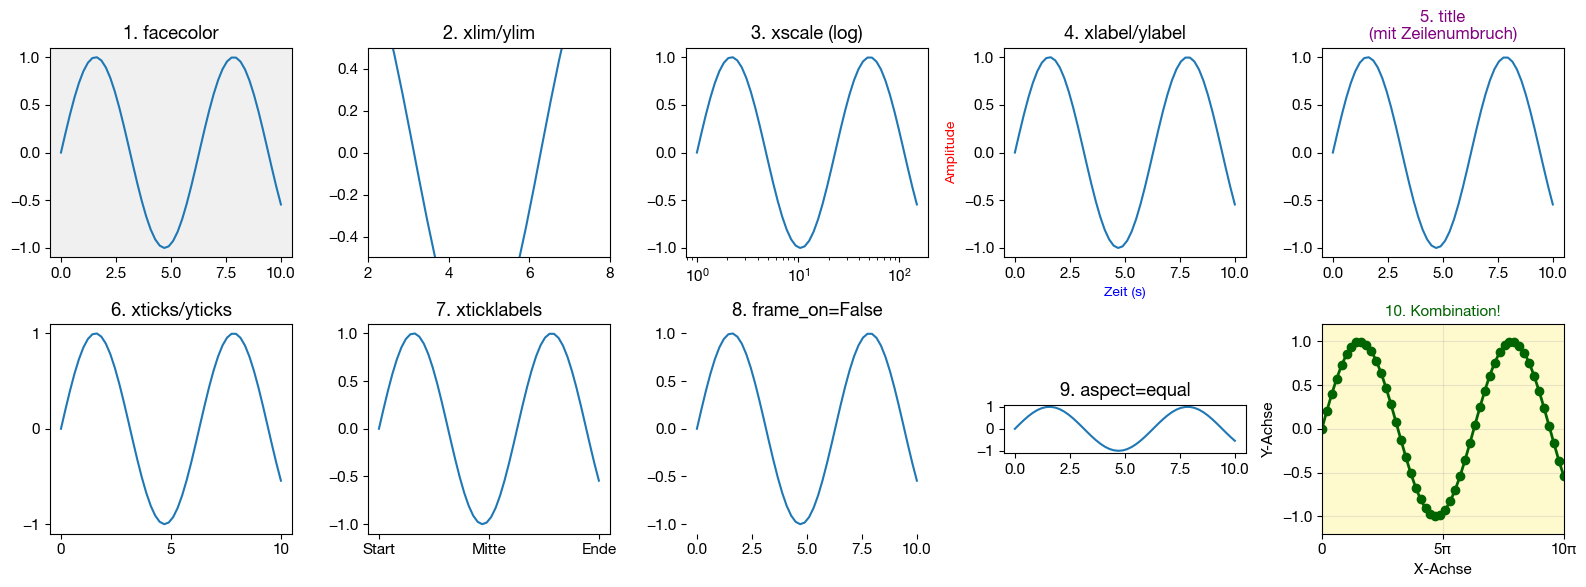

In [124]:
import matplotlib.pyplot as plt
import numpy as np

# Daten vorbereiten
x = np.linspace(0, 10, 50)
y = np.sin(x)

# 10 Subplots für jede Property
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
#Zugriff ist umständlich:
#axes[0][0].plot(...)  # Zeile 0, Spalte 0
#axes[0][1].plot(...)  # Zeile 0, Spalte 1
#axes[1][0].plot(...)  # Zeile 1, Spalte 0
axes = axes.flatten()

# 1. facecolor - Hintergrundfarbe
ax = axes[0]
ax.plot(x, y)
ax.set_facecolor('#f0f0f0')
ax.set_title('1. facecolor')

# 2. xlim / ylim - Achsengrenzen
ax = axes[1]
ax.plot(x, y)
ax.set_xlim(2, 8)
ax.set_ylim(-0.5, 0.5)
ax.set_title('2. xlim/ylim')

# 3. xscale / yscale - Skalierung
ax = axes[2]
ax.plot(np.exp(x/2), y)
ax.set_xscale('log')
ax.set_title('3. xscale (log)')

# 4. xlabel / ylabel - Achsenbeschriftung
ax = axes[3]
ax.plot(x, y)
ax.set_xlabel('Zeit (s)', fontsize=10, color='blue')
ax.set_ylabel('Amplitude', fontsize=10, color='red')
ax.set_title('4. xlabel/ylabel')

# 5. title - Titel
ax = axes[4]
ax.plot(x, y)
ax.set_title('5. title\n(mit Zeilenumbruch)', 
             fontsize=12, fontweight='bold', color='purple')

# 6. xticks / yticks - Tick-Positionen
ax = axes[5]
ax.plot(x, y)
ax.set_xticks([0, 5, 10])
ax.set_yticks([-1, 0, 1])
ax.set_title('6. xticks/yticks')

# 7. xticklabels / yticklabels - Tick-Labels
ax = axes[6]
ax.plot(x, y)
ax.set_xticks([0, 5, 10])
ax.set_xticklabels(['Start', 'Mitte', 'Ende'])
ax.set_title('7. xticklabels')

# 8. frame_on - Rahmen an/aus
ax = axes[7]
ax.plot(x, y)
ax.set_frame_on(False)
ax.set_title('8. frame_on=False')

# 9. aspect - Seitenverhältnis
ax = axes[8]
ax.plot(x, y)
ax.set_aspect('equal')  # oder 'auto', oder Zahl wie 2.0
ax.set_title('9. aspect=equal')

# 10. Kombination - Alle zusammen!
ax = axes[9]
ax.plot(x, y, 'o-', color='darkgreen', linewidth=2)
ax.set_facecolor('#fffacd')
ax.set_xlim(0, 10)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel('X-Achse', fontweight='bold')
ax.set_ylabel('Y-Achse', fontweight='bold')
ax.set_title('10. Kombination!', fontsize=11, color='darkgreen')
ax.set_xticks([0, 5, 10])
ax.set_xticklabels(['0', '5π', '10π'])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


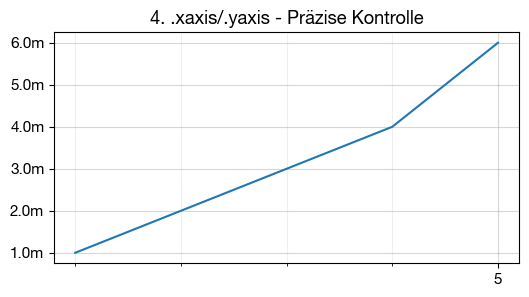

In [121]:
from matplotlib.ticker import MultipleLocator, FuncFormatter

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x, y)

# Major Ticks alle 5 Einheiten
ax.xaxis.set_major_locator(MultipleLocator(5))

# Minor Ticks alle 1 Einheit
ax.xaxis.set_minor_locator(MultipleLocator(1))

# Custom Formatter für Y-Achse
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.1f}m'))

# Grid für Minor Ticks
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)

plt.title("4. .xaxis/.yaxis - Präzise Kontrolle")
plt.show()
#---


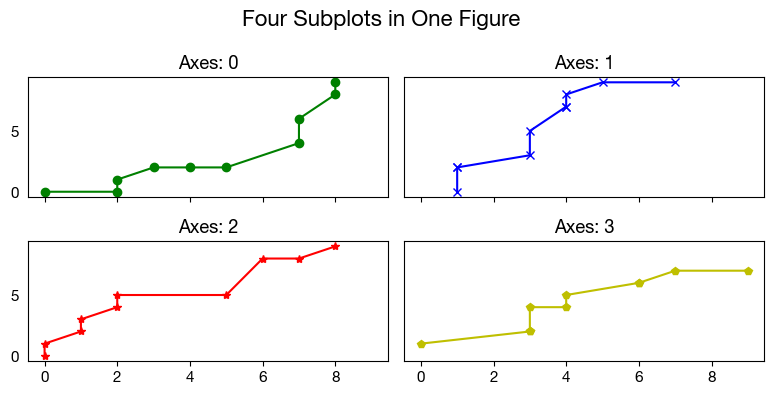

In [122]:

np.random.seed(100)

# create Figure and Subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 4), dpi=100,
                         sharex=True, sharey=True)

# define the colors and markers to use
colors = {0:'g', 1:'b', 2:'r', 3:'y'}
markers = {0:'o', 1:'x', 2:'*', 3:'p'}

# plot each axes
for i, ax in enumerate(axes.ravel()): # I use ravel() to obtain a 1D array from a 2x2 matrix
    # generate random data
    xvals = sorted(np.random.randint(0, 10, 10))
    yvals = sorted(np.random.randint(0, 10, 10))

    ax.plot(xvals, yvals, marker=markers[i], color=colors[i])
    ax.set_title(f'Axes: {i}')
    ax.yaxis.set_ticks_position('none')

plt.suptitle('Four Subplots in One Figure', fontsize=16)
plt.tight_layout()
plt.show()

Things to notice:

1. you can specify marker type, color, and line through dedicated arguments within `plot()`, instead of using the `fmt` string
1. Y axis ticks were switched off with `ax.yaxis.set_ticks_position("none")`

Another advantage of the OO interface is the possibility to set a dynamic title for each subplot.

You can actually get a reference to any specific element of the plot and use its methods to manipulate it.

`plt.suptitle()` adds a main title at figure level.
(`plt.title()` would have done the same for the current subplot)

So far you have learned the core essence creating and manipulating a plot using `matplotlib`.
Next, let’s see how to modify other components of the plot.

[4 3 2 1 0]
4
3
2
1
0


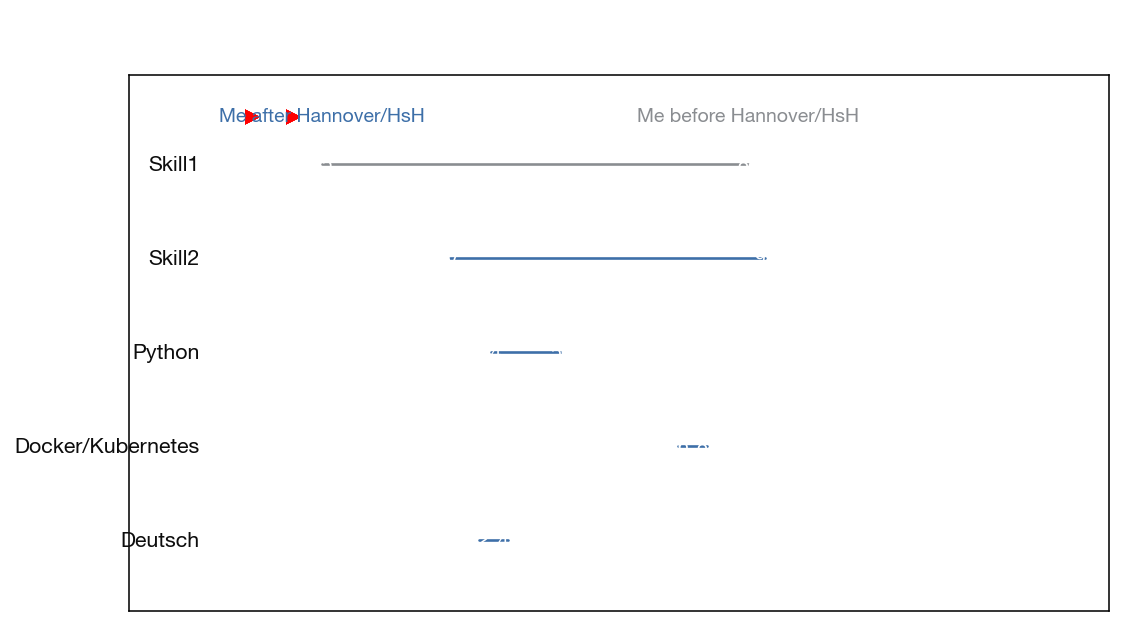

In [130]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
        "font.size": 11,
    }
)

BLUE = "#3d6fa8"
GREY = "#8a8d91"

traits = [
    "Skill1",
    "Skill2",
    "Python",
    "Docker/Kubernetes",
    "Deutsch",
]
##load_data() - pd.readCsv() => converting it to a np.array()

#Daten
def load_data():
    ##load_data() - pd.readCsv() => converting it to a np.array()
    friend = np.array([15, 91, 56, 81, 47])
    me = np.array([88, 37, 44, 76, 42])
    return friend, me

friend, me = load_data()

n = len(traits)
y = np.arange(n)[::-1]  # top row = Extraversion
print(y)

#Größe
r_dot = 520  # marker area (points^2); tune for figure size
fig, ax = plt.subplots(figsize=(8.2, 4.6), dpi=140)



#Data Visualization process/pipeline
ax.set_facecolor("white")
for yi, tr, fv, mv in zip(y, traits, friend, me):
    lo, hi = sorted((fv, mv))
    # Connector colour = colour of the *higher* score (grey = Me, blue = Friend)
    line_color = GREY if mv > fv else BLUE
    print(yi)
    ax.plot([lo, hi], [yi, yi], solid_capstyle="round", color=line_color, linewidth=1.35, zorder=1)
    ax.plot([3, 10], [4.5, 4.5], 'r>')
    #ax.scatter([fv], [yi], s=r_dot, c=BLUE, zorder=3, edgecolors="white", linewidth=0.6)
    #ax.scatter([mv], [yi], s=r_dot, c=GREY, zorder=3, edgecolors="white", linewidth=0.6)
    ax.text(fv, yi, str(int(fv)), ha="center", va="center", color="white", fontweight="bold", fontsize=10, zorder=4)
    ax.text(mv, yi, str(int(mv)), ha="center", va="center", color="white", fontweight="bold", fontsize=10, zorder=4)
    ax.text(-6, yi, tr, ha="right", va="center", fontweight="bold", color="0.05", fontsize=11)

# Integrated header on the first row (Extraversion)
y0 = y[0]
ax.text(friend[0], y0 + 0.42, "Me after Hannover/HsH", ha="center", va="bottom", color=BLUE, fontsize=10, fontweight="semibold")
ax.text(me[0], y0 + 0.42, "Me before Hannover/HsH", ha="center", va="bottom", color=GREY, fontsize=10, fontweight="semibold")

ax.set_title(
    "  ",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color="0.05",
    pad=22,
)

for s in ax.spines.values():
    #s.set_visible(False)
    #s.set_color("black")
    t='t'
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_xlim(-18, 150)
ax.set_ylim(y.min() - 0.75, y.max() + 0.95)

plt.tight_layout()
plt.show()

## .{x.y}lim & .{x,y}bound

The first thing we might want to configure is the ranges of the axes. We can do this using the `set_ylim` and `set_xlim` methods in the axis object, or `axis('tight')` for automatrically getting "tightly fitted" axes ranges:

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, x, x**3) # note how you can also provide several x-y pairs
ax.set_xlim([2, 5])
ax.set_ylim([0, 60])
ax.set_title("Custom axes range")
plt.show()

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, x, x**3) # note how you can also provide several x-y pairs
ax.axis("tight")
ax.set_title("Tight axes")
plt.show()

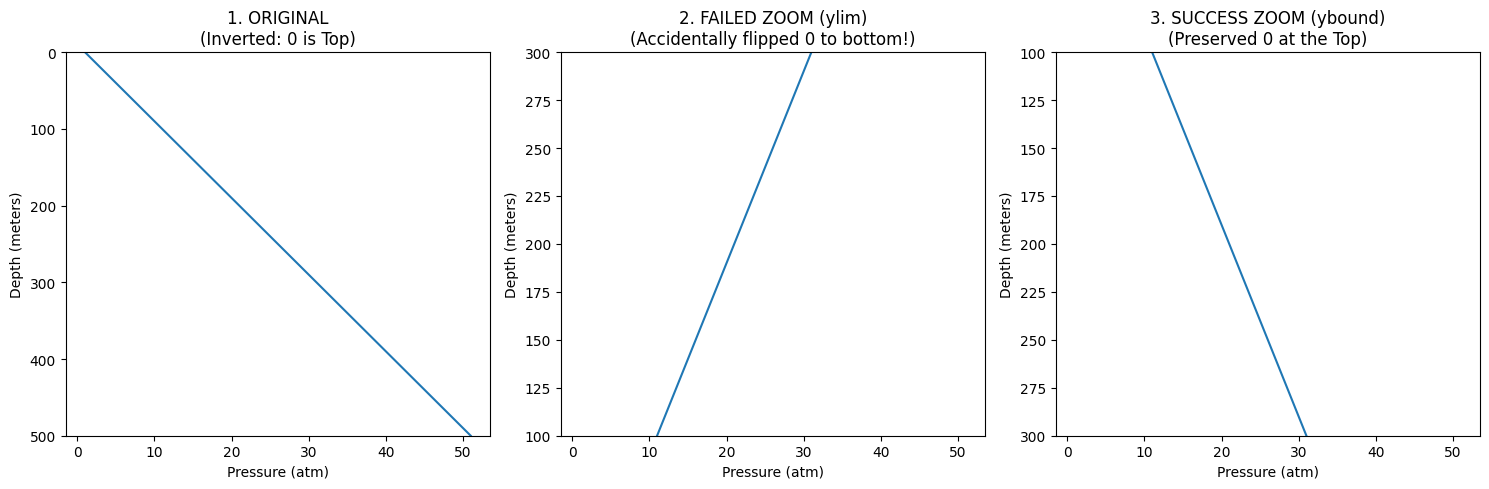

In [ ]:
import matplotlib.pyplot as plt

# Create data for a "Depth" plot (e.g., Ocean Pressure)
depth = [0, 100, 200, 300, 400, 500]
pressure = [1, 11, 21, 31, 41, 51]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# --- 1. THE SETUP ---
# We want 0 at the top (Surface) and 500 at the bottom (Deep)
for ax in [ax1, ax2, ax3]:
    ax.plot(pressure, depth)
    ax.set_ylim(500, 0) # INVERTED: High number at bottom
    ax.set_ylabel("Depth (meters)")
    ax.set_xlabel("Pressure (atm)")

ax1.set_title("1. ORIGINAL\n(Inverted: 0 is Top)")

# --- 2. THE "FAILURE" WITH ylim ---
# I want to zoom in on 100m to 300m. 
# But I pass them in 'natural' order (100, 300)...
ax2.set_ylim(100, 300) 
ax2.set_title("2. FAILED ZOOM (ylim)\n(Accidentally flipped 0 to bottom!)")

# --- 3. THE "SUCCESS" WITH ybound ---
# I use the exact same numbers, but with ybound.
ax3.set_ybound(100, 300) 
ax3.set_title("3. SUCCESS ZOOM (ybound)\n(Preserved 0 at the Top)")

plt.tight_layout()
plt.show()

## Logarithmic scale

In [ ]:
fig, axes = plt.subplots(1, 2)

axes[0].plot(x, x**2, x, np.exp(x))
axes[0].set_title("Normal scale")

axes[1].plot(x, x**2, x, np.exp(x))
axes[1].set_yscale("log")
axes[1].set_title("Logarithmic scale (y)")

plt.show()

## Placement of ticks and custom tick labels

We can explicitly determine where we want the axis ticks with `set_xticks` and `set_yticks`, which both take a list of values for where on the axis the ticks are to be placed. We can also use the `set_xticklabels` and `set_yticklabels` methods to provide a list of custom text labels for each tick location:

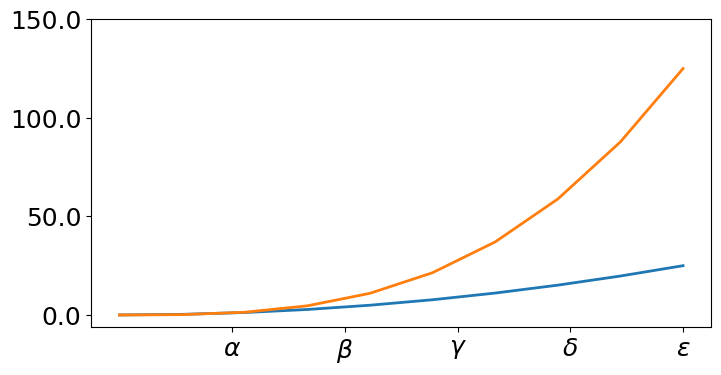

In [ ]:
x = np.linspace(0, 5, 10)

xticks = [1, 2, 3, 4, 5]
custom_xticklabels = [r'$\alpha$', r'$\beta$', r'$\gamma$', r'$\delta$', r'$\epsilon$']

yticks = [0, 50, 100, 150]
custom_yticklabels = [f"{y:.1f}" for y in yticks]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, x**2, x, x**3, lw=2)
ax.set_xticks(xticks)
ax.set_xticklabels(custom_xticklabels, fontsize=18)
ax.set_yticks(yticks)
ax.set_yticklabels(custom_yticklabels, fontsize=18)

plt.show()

**Scientific notation**

With large numbers on x or y axis, it is often better use scientific notation: to this end, with an Axes `ax` object we use `ax.xaxis.set_major_formatter(formatter)` (`ax.yaxis.set_major_formatter(formatter)`) with a Formatter object.

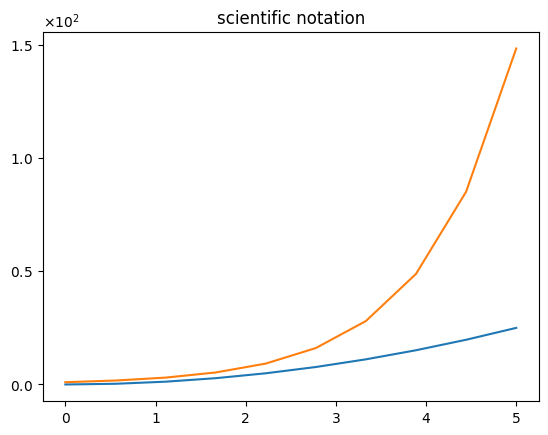

In [ ]:
fig, ax = plt.subplots(1, 1)

ax.plot(x, x**2, x, np.exp(x))
ax.set_title("scientific notation")

ax.set_yticks(yticks)

from matplotlib import ticker
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1,1))
ax.yaxis.set_major_formatter(formatter)

plt.show()